# BC카드 소비데이터: 불확실성 인지형 소비구조 EDA와 MCMC

이 노트북은 공모전 원자료 `ABP_CONTEST_DATA.csv`를 **수정하지 않고** 읽어, EDA·전처리·계층 베이지안 분포모형을 재현한다.

분석 질문은 “어느 상권이 성장했는가”가 아니다. 2026년 1–6월의 BC카드 관측 소비에서, 특정 업종의 지역·성별·연령별 **거래당 결제금액 구조가 기준선보다 높을 확률**을 불확실성과 함께 추정한다. 인구와 업소 수가 결합된 뒤에만 수요-공급 공백으로 확장한다.

**해석 경계**

- BC카드 집계는 전체 카드시장이나 실제 개별 매장 매출이 아니다.
- 파일에 없는 조합은 0으로 채우지 않는다. 0건 미제공인지, 소액 억제인지 플랫폼 규칙이 확인되기 전에는 식별할 수 없다.
- 월 더미는 달력 보정이며 추세·성장·쇠퇴를 추정하지 않는다.
- 외국인과 법인은 대응 노출량이 없으므로, 창업 순위에는 넣지 않고 소비구성 EDA로만 남긴다.


In [1]:
from pathlib import Path
import warnings

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import pymc as pm

RNG_SEED = 20260913
RAW_PATH = Path("../ABP_CONTEST_DATA.csv")
if not RAW_PATH.exists():
    RAW_PATH = Path("ABP_CONTEST_DATA.csv")

FOCUS_INDUSTRY = "서양음식"  # 11개 업종 중 하나로 바꿔 업종별로 적합한다.
FAST_MODE = False            # True는 구조 점검용; 제출용 결과에는 False를 유지한다.
DRAWS = 100 if FAST_MODE else 1_000
TUNE = 100 if FAST_MODE else 1_000
CHAINS = 2 if FAST_MODE else 4
TARGET_ACCEPT = 0.95
EFFECTIVE_COUNT_CAP = 2_000  # 집계자료의 과도한 유효 표본수를 막는 민감도 파라미터

plt.rcParams["figure.dpi"] = 120
np.set_printoptions(suppress=True, precision=3)


## 1. 원자료 무결성 검사와 코드북 대조

In [2]:
REQUIRED_COLUMNS = [
    "STRD_YYMM", "SIDO_NM", "CCG_NM", "GENDER_CD", "AGE_CD",
    "TP_BUZ_NO", "TP_BUZ_NM", "amt", "cnt",
]
KEY_COLUMNS = ["STRD_YYMM", "SIDO_NM", "CCG_NM", "GENDER_CD", "AGE_CD", "TP_BUZ_NO"]

df = pl.read_csv(
    RAW_PATH,
    schema_overrides={"GENDER_CD": pl.Utf8, "AGE_CD": pl.Utf8},
).with_columns(
    pl.concat_str(["SIDO_NM", "CCG_NM"], separator=" | ").alias("region_id"),
    (pl.col("amt") / pl.col("cnt")).alias("ticket"),
)

assert df.columns[:9] == REQUIRED_COLUMNS, f"Unexpected schema: {df.columns}"
assert df.null_count().select(pl.sum_horizontal(pl.all())).item() == 0, "Nulls must be investigated."
assert df.height == df.unique(subset=KEY_COLUMNS).height, "The stated grain is not unique."
assert df.filter((pl.col("amt") <= 0) | (pl.col("cnt") <= 0)).is_empty(), "Nonpositive amount/count found."
assert df.select((pl.col("amt") % 10_000 == 0).all()).item(), "Rounding rule differs from expected 10,000 KRW."

quality = pl.DataFrame({
    "check": ["rows", "months", "region pairs", "industries", "complete duplicates", "min cnt", "min amount"],
    "value": [
        df.height,
        df.select(pl.col("STRD_YYMM").n_unique()).item(),
        df.select(pl.struct(["SIDO_NM", "CCG_NM"]).n_unique()).item(),
        df.select(pl.col("TP_BUZ_NO").n_unique()).item(),
        df.height - df.unique().height,
        df.select(pl.col("cnt").min()).item(),
        df.select(pl.col("amt").min()).item(),
    ],
})
quality


check,value
str,i64
"""rows""",242574
"""months""",6
"""region pairs""",255
"""industries""",11
"""complete duplicates""",0
"""min cnt""",11
"""min amount""",20000


In [3]:
months = df.select(pl.col("STRD_YYMM").unique().sort()).to_series().to_list()
regions = df.select(["SIDO_NM", "CCG_NM"]).unique().height
industries = df.select("TP_BUZ_NO").n_unique()
segments = df.select(["GENDER_CD", "AGE_CD"]).unique().height
possible_cells = len(months) * regions * industries * segments

coverage = pl.DataFrame({
    "metric": ["observed cells", "possible cells from observed levels", "observed share", "unobserved share"],
    "value": [df.height, possible_cells, df.height / possible_cells, 1 - df.height / possible_cells],
}, schema_overrides={"value": pl.Float64})
print("Observed gender-age combinations:")
print(df.group_by(["GENDER_CD", "AGE_CD"]).len().sort(["GENDER_CD", "AGE_CD"]))
coverage


Observed gender-age combinations:
shape: (19, 3)
┌───────────┬────────┬───────┐
│ GENDER_CD ┆ AGE_CD ┆ len   │
│ ---       ┆ ---    ┆ ---   │
│ str       ┆ str    ┆ u32   │
╞═══════════╪════════╪═══════╡
│ 1         ┆ 1      ┆ 12181 │
│ 1         ┆ 2      ┆ 13241 │
│ 1         ┆ 3      ┆ 13480 │
│ 1         ┆ 4      ┆ 13679 │
│ 1         ┆ 5      ┆ 13929 │
│ …         ┆ …      ┆ …     │
│ 3         ┆ 3      ┆ 12564 │
│ 3         ┆ 4      ┆ 12641 │
│ 3         ┆ 5      ┆ 12702 │
│ 3         ┆ 6      ┆ 12553 │
│ x         ┆ x      ┆ 13161 │
└───────────┴────────┴───────┘


metric,value
str,f64
"""observed cells""",242574.0
"""possible cells from observed l…",319770.0
"""observed share""",0.758589
"""unobserved share""",0.241411


The `x/x` row is handled as corporate consumption because it is the only non-age-specific combination. The source data contain foreign consumers (`GENDER_CD=3`) with ages 1–6, contrary to the supplied prose description. The raw codes, rather than the prose description, determine the data pipeline; the semantic interpretation still needs platform confirmation.

## 2. 소비구조 EDA: 금액, 거래건수, 객단가

In [4]:
market_summary = df.select(
    pl.col("amt").sum().alias("total_amount_krw"),
    pl.col("cnt").sum().alias("total_transactions"),
    (pl.col("amt").sum() / pl.col("cnt").sum()).alias("weighted_ticket_krw"),
    pl.col("ticket").median().alias("cell_ticket_median_krw"),
    pl.col("ticket").quantile(0.99).alias("cell_ticket_p99_krw"),
)
industry_summary = (
    df.group_by(["TP_BUZ_NO", "TP_BUZ_NM"])
    .agg(
        pl.col("amt").sum().alias("amount_krw"),
        pl.col("cnt").sum().alias("transactions"),
        (pl.col("amt").sum() / pl.col("cnt").sum()).alias("weighted_ticket_krw"),
    )
    .with_columns((pl.col("amount_krw") / pl.col("amount_krw").sum()).alias("amount_share"))
    .sort("amount_krw", descending=True)
)
demographic_summary = (
    df.with_columns(
        pl.when(pl.col("GENDER_CD").is_in(["1", "2"]))
        .then(pl.lit("domestic_individual"))
        .when(pl.col("GENDER_CD") == "3")
        .then(pl.lit("foreign"))
        .otherwise(pl.lit("corporate"))
        .alias("consumer_class")
    )
    .group_by("consumer_class")
    .agg(pl.col("amt").sum().alias("amount_krw"), pl.col("cnt").sum().alias("transactions"))
    .with_columns((pl.col("amount_krw") / pl.col("amount_krw").sum()).alias("amount_share"))
    .sort("amount_krw", descending=True)
)
print(market_summary)
print(industry_summary)
print(demographic_summary)


shape: (1, 5)
┌──────────────────┬───────────────────┬───────────────────┬───────────────────┬───────────────────┐
│ total_amount_krw ┆ total_transaction ┆ weighted_ticket_k ┆ cell_ticket_media ┆ cell_ticket_p99_k │
│ ---              ┆ s                 ┆ rw                ┆ n_krw             ┆ rw                │
│ i64              ┆ ---               ┆ ---               ┆ ---               ┆ ---               │
│                  ┆ i64               ┆ f64               ┆ f64               ┆ f64               │
╞══════════════════╪═══════════════════╪═══════════════════╪═══════════════════╪═══════════════════╡
│ 17224900070000   ┆ 949105068         ┆ 18148.570322      ┆ 18223.412901      ┆ 87960.199005      │
└──────────────────┴───────────────────┴───────────────────┴───────────────────┴───────────────────┘
shape: (11, 6)
┌───────────┬────────────┬───────────────┬──────────────┬─────────────────────┬──────────────┐
│ TP_BUZ_NO ┆ TP_BUZ_NM  ┆ amount_krw    ┆ transactions ┆ weighted_t

/tmp/ipykernel_2748596/1301750167.py:11: UserWarning: Glyph 54620 (\N{HANGUL SYLLABLE HAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2748596/1301750167.py:11: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2748596/1301750167.py:11: UserWarning: Glyph 49885 (\N{HANGUL SYLLABLE SIG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2748596/1301750167.py:11: UserWarning: Glyph 44040 (\N{HANGUL SYLLABLE GAL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2748596/1301750167.py:11: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2748596/1301750167.py:11: UserWarning: Glyph 51204 (\N{HANGUL SYLLABLE JEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2748596/1301750167.py:11: UserWarning: Glyph 47928 (\N{HANGUL SYLLABLE MUN}) missing from font(s) Dej

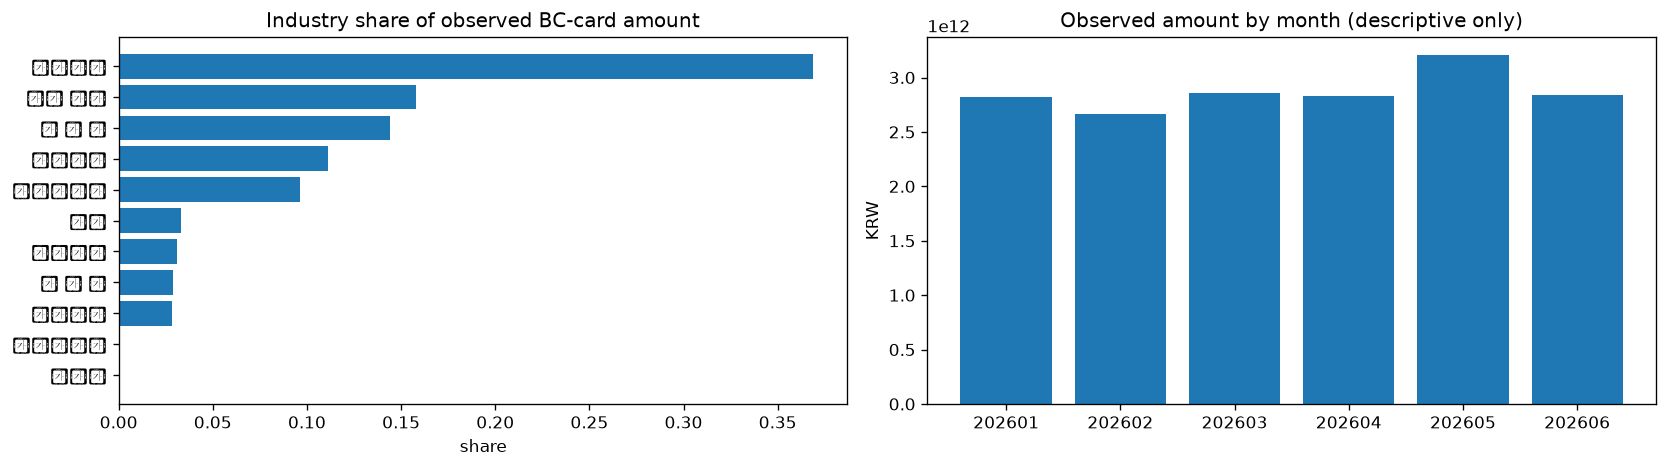

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_industry = industry_summary.sort("amount_share")
axes[0].barh(plot_industry["TP_BUZ_NM"].to_list(), plot_industry["amount_share"].to_list())
axes[0].set_title("Industry share of observed BC-card amount")
axes[0].set_xlabel("share")

monthly = df.group_by("STRD_YYMM").agg(pl.col("amt").sum().alias("amount_krw")).sort("STRD_YYMM")
axes[1].bar(monthly["STRD_YYMM"].cast(pl.Utf8).to_list(), monthly["amount_krw"].to_list())
axes[1].set_title("Observed amount by month (descriptive only)")
axes[1].set_ylabel("KRW")
plt.tight_layout()


## 3. 전처리: 내국인 개인 분석 표본과 결측의 보존

In [6]:
DOMESTIC_GENDERS = ["1", "2"]
DOMESTIC_AGES = ["1", "2", "3", "4", "5", "6"]

domestic = df.filter(
    pl.col("GENDER_CD").is_in(DOMESTIC_GENDERS)
    & pl.col("AGE_CD").is_in(DOMESTIC_AGES)
)

# Deliberately no complete-grid expansion: an absent raw row is not identified as zero.
focus = domestic.filter(pl.col("TP_BUZ_NM") == FOCUS_INDUSTRY)
assert focus.height > 0, f"Unknown FOCUS_INDUSTRY: {FOCUS_INDUSTRY}"

focus_summary = focus.select(
    pl.len().alias("observed_positive_cells"),
    pl.col("region_id").n_unique().alias("districts"),
    pl.concat_str(["GENDER_CD", "AGE_CD"], separator="_").n_unique().alias("sex_age_segments"),
    pl.col("STRD_YYMM").n_unique().alias("months"),
    pl.col("ticket").median().alias("median_ticket_krw"),
)
focus_summary


observed_positive_cells,districts,sex_age_segments,months,median_ticket_krw
u32,u32,u32,u32,f64
18319,255,12,6,11106.823721


## 4. 즉시 실행 가능한 계층 Gamma 객단가 모형

외부 인구·업소 파일이 없는 현재도, 금액을 거래건수에 조건부로 모델링할 수 있다.

\[
M_i=A_i/C_i \mid C_i^*,\mu_i,\kappa \sim \operatorname{Gamma}(C_i^*\kappa,\; C_i^*\kappa/\mu_i), \qquad
\log\mu_i=\alpha+d_{\mathrm{district}[i]}+s_{\mathrm{segment}[i]}+m_{\mathrm{month}[i]}.
\]

여기서 \(A_i\)는 집계 결제금액, \(M_i=A_i/C_i\)는 관측 객단가, \(C_i\)는 거래건수, \(C_i^*=\min(C_i,2{,}000)\)는 보수적으로 상한을 둔 유효 거래수, \(\mu_i\)는 거래당 금액이다. 지역·집단·월 효과는 평균 0의 계층 prior로 부분 풀링한다. 월 효과는 달력 보정이며 선형 추세가 아니다.

이 모형의 결과는 **상대적 객단가 신호**다. 인구·업소 수가 없으므로 이 결과만으로 창업 입지의 수요-공급 공백이나 실제 매출을 말하지 않는다.

In [7]:
model_frame = focus.select([
    "region_id", "GENDER_CD", "AGE_CD", "STRD_YYMM", "amt", "cnt", "ticket",
]).with_columns(
    pl.concat_str(["GENDER_CD", "AGE_CD"], separator="_").alias("segment_id"),
    pl.min_horizontal(pl.col("cnt"), pl.lit(EFFECTIVE_COUNT_CAP)).cast(pl.Float64).alias("effective_cnt"),
)

# A deterministic ordering makes posterior arrays reproducible and labels them in ArviZ.
district_levels = model_frame.get_column("region_id").unique().sort().to_list()
segment_levels = model_frame.get_column("segment_id").unique().sort().to_list()
month_levels = model_frame.get_column("STRD_YYMM").unique().sort().to_list()
district_index = {v: i for i, v in enumerate(district_levels)}
segment_index = {v: i for i, v in enumerate(segment_levels)}
month_index = {v: i for i, v in enumerate(month_levels)}

region_idx = np.array([district_index[v] for v in model_frame["region_id"].to_list()], dtype="int64")
segment_idx = np.array([segment_index[v] for v in model_frame["segment_id"].to_list()], dtype="int64")
month_idx = np.array([month_index[v] for v in model_frame["STRD_YYMM"].to_list()], dtype="int64")
ticket_observed = model_frame["ticket"].to_numpy().astype("float64")
effective_cnt = model_frame["effective_cnt"].to_numpy().astype("float64")

coords = {
    "observation": np.arange(model_frame.height),
    "district": district_levels,
    "segment": segment_levels,
    "month": month_levels,
}
print(f"Fitting {FOCUS_INDUSTRY}: {model_frame.height:,} positive cells, {len(district_levels)} districts")


Fitting 서양음식: 18,319 positive cells, 255 districts


In [8]:
with pm.Model(coords=coords) as ticket_model:
    district_idx = pm.Data("district_idx", region_idx, dims="observation")
    segment_idx_data = pm.Data("segment_idx", segment_idx, dims="observation")
    month_idx_data = pm.Data("month_idx", month_idx, dims="observation")
    count_weight = pm.Data("effective_cnt", effective_cnt, dims="observation")

    intercept = pm.Normal("intercept", mu=np.log(18_000), sigma=1.5)
    sigma_district = pm.HalfNormal("sigma_district", sigma=0.7)
    sigma_segment = pm.HalfNormal("sigma_segment", sigma=0.7)
    sigma_month = pm.HalfNormal("sigma_month", sigma=0.4)

    # 셀마다 거래가 많아 데이터가 강하다. non-centered(offset×sigma)는 sigma_district R-hat 1.07·ESS 45로 실패했으므로
    # centered 합-0 효과를 쓴다.
    district_effect = pm.ZeroSumNormal("district_effect", sigma=sigma_district, dims="district")
    segment_effect = pm.ZeroSumNormal("segment_effect", sigma=sigma_segment, dims="segment")
    month_effect = pm.ZeroSumNormal("month_effect", sigma=sigma_month, dims="month")

    log_mean_ticket = (
        intercept
        + district_effect[district_idx]
        + segment_effect[segment_idx_data]
        + month_effect[month_idx_data]
    )
    mean_ticket = pm.Deterministic("mean_ticket", pm.math.exp(log_mean_ticket), dims="observation")
    kappa = pm.Exponential("kappa", lam=1.0)
    pm.Gamma(
        "ticket_obs",
        alpha=count_weight * kappa,
        beta=(count_weight * kappa) / mean_ticket,
        observed=ticket_observed,
        dims="observation",
    )

    idata = pm.sample(
        draws=DRAWS,
        tune=TUNE,
        chains=CHAINS,
        nuts_sampler="numpyro",  # JAX GPU
        nuts_sampler_kwargs={"chain_method": "vectorized"},
        target_accept=TARGET_ACCEPT,
        random_seed=RNG_SEED,
        progressbar=True,
        return_inferencedata=True,
    )
    idata = pm.sample_posterior_predictive(
        idata,
        var_names=["ticket_obs"],
        random_seed=RNG_SEED,
        extend_inferencedata=True,
        progressbar=True,
    )


/tmp/ipykernel_2748596/3024546550.py:34: FutureWarning: `nuts_sampler_kwargs` is deprecated. Pass NUTS keyword arguments via the `nuts={...}` argument to `pm.sample`.
  idata = pm.sample(
NUTS[numpyro]: [intercept, sigma_district, sigma_segment, sigma_month, district_effect, segment_effect, month_effect, kappa]


  0%|          | 0/2000 [00:00<?, ?it/s]

warmup:   5%|▌         | 100/2000 [00:11<03:44,  8.48it/s]

warmup:  10%|█         | 200/2000 [00:18<02:37, 11.40it/s]

warmup:  15%|█▌        | 300/2000 [00:21<01:46, 15.98it/s]

...

sample:  95%|█████████▌| 1900/2000 [00:50<00:01, 71.35it/s]

sample: 100%|██████████| 2000/2000 [00:51<00:00, 71.97it/s]

sample: 100%|██████████| 2000/2000 [00:51<00:00, 38.94it/s]

Sampling: [ticket_obs]


Output()

## 5. 수렴과 사후예측검사

               ess_bulk ess_tail r_hat mcse_mean  mcse_sd
intercept          4588     3012  1.00   1.1e-05  1.1e-05
sigma_district     8090     3132  1.00     9e-05  0.00015
sigma_segment      8316     2105  1.00   0.00051  0.00091
sigma_month        7544     2691  1.00    0.0005   0.0011
kappa              9716     2888  1.00     1e-05  1.7e-05
r_hat          1.006291
ess_bulk    3426.517805
ess_tail    2065.467249
Divergences: 0


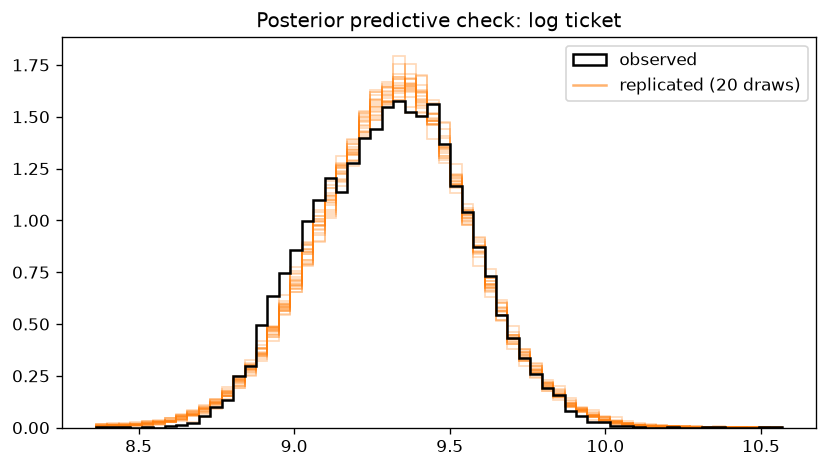

In [9]:
diagnostics = az.summary(
    idata,
    var_names=["intercept", "sigma_district", "sigma_segment", "sigma_month", "kappa",
               "district_effect", "segment_effect", "month_effect"],
    kind="diagnostics",
)
print(diagnostics.loc[["intercept", "sigma_district", "sigma_segment", "sigma_month", "kappa"]])
print(diagnostics.agg({"r_hat": "max", "ess_bulk": "min", "ess_tail": "min"}).to_string())  # 효과 벡터 포함 최악값

rhat = diagnostics["r_hat"].dropna()
if not rhat.empty and (rhat >= 1.01).any():
    warnings.warn("R-hat >= 1.01. Increase tune/draws; do not use this run for a decision.")
if (diagnostics[["ess_bulk", "ess_tail"]] < 400).any().any():
    warnings.warn("ESS < 400. Do not use this run for a decision.")
if "diverging" in idata.sample_stats:
    divergences = int(idata.sample_stats["diverging"].sum().item())
    print(f"Divergences: {divergences}")
    if divergences:
        warnings.warn("Divergences present. Reparameterize or revise priors; do not hide them by only raising target_accept.")

posterior_predictive = idata.posterior_predictive["ticket_obs"].stack(sample=("chain", "draw")).values
observed_log_ticket = np.log(ticket_observed)
replicated_log_ticket = np.log(posterior_predictive)

# 관측 분포 vs 사후예측 복제 분포(무작위 draw 20개). 관측별 중앙값을 비교하면 예측분포의 퍼짐이 사라진다.
draws_to_plot = np.random.default_rng(RNG_SEED).choice(replicated_log_ticket.shape[1], 20, replace=False)
fig, ax = plt.subplots(figsize=(7, 4))
bins = np.histogram_bin_edges(observed_log_ticket, bins=60)
for k in draws_to_plot:
    ax.hist(replicated_log_ticket[:, k], bins=bins, density=True, histtype="step", color="C1", alpha=0.3)
ax.hist(observed_log_ticket, bins=bins, density=True, histtype="step", color="k", linewidth=1.5, label="observed")
ax.plot([], [], color="C1", alpha=0.6, label="replicated (20 draws)")
ax.set_title("Posterior predictive check: log ticket")
ax.legend()
plt.tight_layout()

In [10]:
district_effect_draws = idata.posterior["district_effect"].stack(sample=("chain", "draw")).transpose("district", "sample").values

ticket_signal = pl.DataFrame({
    "region_id": district_levels,
    "posterior_mean_log_ticket_effect": district_effect_draws.mean(axis=1),
    "ci90_low": np.quantile(district_effect_draws, 0.05, axis=1),
    "ci90_high": np.quantile(district_effect_draws, 0.95, axis=1),
    "probability_above_baseline": (district_effect_draws > 0).mean(axis=1),
}).with_columns(
    pl.when((pl.col("probability_above_baseline") >= 0.80) & (pl.col("ci90_low") > 0))
    .then(pl.lit("high-confidence ticket signal"))
    .when(pl.col("probability_above_baseline") >= 0.60)
    .then(pl.lit("pilot-test signal"))
    .otherwise(pl.lit("uncertain / no action"))
    .alias("evidence_tier")
).sort(["probability_above_baseline", "posterior_mean_log_ticket_effect"], descending=True)

ticket_signal.head(20)


region_id,posterior_mean_log_ticket_effect,ci90_low,ci90_high,probability_above_baseline,evidence_tier
str,f64,f64,f64,f64,str
"""경상북도 | 울릉군""",0.533283,0.49118,0.576042,1.0,"""high-confidence ticket signal"""
"""서울특별시 | 용산구""",0.440344,0.426638,0.4542,1.0,"""high-confidence ticket signal"""
"""강원특별자치도 | 고성군""",0.438674,0.420178,0.457729,1.0,"""high-confidence ticket signal"""
"""경상남도 | 남해군""",0.438633,0.421418,0.455929,1.0,"""high-confidence ticket signal"""
"""강원특별자치도 | 양양군""",0.411045,0.39073,0.431012,1.0,"""high-confidence ticket signal"""
…,…,…,…,…,…
"""전라남도 | 담양군""",0.280613,0.264641,0.296921,1.0,"""high-confidence ticket signal"""
"""충청남도 | 청양군""",0.26023,0.229841,0.290496,1.0,"""high-confidence ticket signal"""
"""강원특별자치도 | 홍천군""",0.256996,0.240006,0.274116,1.0,"""high-confidence ticket signal"""


The tier above is deliberately a **ticket-value** evidence tier, not an opening recommendation. It says only whether a district's observed transaction amount conditional on the modelled covariates is above the selected industry's baseline with a stated probability.

## 6. 외부 데이터 결합 후: 거래빈도와 공급 보정 확장

In [11]:
POPULATION_PATH = Path("../data/external/population_sgg_age_sex.csv")
ESTABLISHMENTS_PATH = Path("../data/external/establishments_sgg_industry.csv")
if not POPULATION_PATH.exists():
    POPULATION_PATH = Path("data/external/population_sgg_age_sex.csv")
if not ESTABLISHMENTS_PATH.exists():
    ESTABLISHMENTS_PATH = Path("data/external/establishments_sgg_industry.csv")


def build_demand_panel(domestic_data: pl.DataFrame, population_path: Path, establishments_path: Path) -> pl.DataFrame:
    """Return a 6-month domestic demand panel; refuse unverified external joins."""
    population = pl.read_csv(population_path, schema_overrides={"GENDER_CD": pl.Utf8, "AGE_CD": pl.Utf8})
    establishments = pl.read_csv(establishments_path)
    population_key = ["SIDO_NM", "CCG_NM", "GENDER_CD", "AGE_CD"]
    establishments_key = ["SIDO_NM", "CCG_NM", "TP_BUZ_NO"]
    assert set(population_key + ["population"]).issubset(population.columns)
    assert set(establishments_key + ["establishments"]).issubset(establishments.columns)
    assert population.height == population.unique(subset=population_key).height, "Duplicate population key."
    assert establishments.height == establishments.unique(subset=establishments_key).height, "Duplicate establishments key."
    assert population.filter(pl.col("population") <= 0).is_empty(), "Population must be positive."
    assert establishments.filter(pl.col("establishments") <= 0).is_empty(), "Establishments must be positive."

    panel = (
        domestic_data.group_by(establishments_key + ["GENDER_CD", "AGE_CD"])
        .agg(pl.col("cnt").sum().alias("transactions"), pl.col("amt").sum().alias("amount_krw"))
        .join(population, on=population_key, how="left")
        .join(establishments, on=establishments_key, how="left")
    )
    missing = panel.filter(pl.col("population").is_null() | pl.col("establishments").is_null())
    if missing.height:
        raise ValueError(f"External data do not cover {missing.height:,} observed positive cells; do not impute them.")
    return panel.with_columns(
        (pl.col("amount_krw") / pl.col("transactions")).alias("ticket"),
        pl.concat_str(["SIDO_NM", "CCG_NM"], separator=" | ").alias("region_id"),
    )

if POPULATION_PATH.exists() and ESTABLISHMENTS_PATH.exists():
    demand_panel = build_demand_panel(domestic, POPULATION_PATH, ESTABLISHMENTS_PATH)
    print(demand_panel.head())
    print(f"External panel ready: {demand_panel.height:,} observed positive cells")
else:
    print("External files are not present. Read data/external/README.md before fitting a demand or supply-gap model.")


External files are not present. Read data/external/README.md before fitting a demand or supply-gap model.


With a complete external panel, fit the following negative-binomial model to `transactions`; do not use it until the area and industry mappings have been audited.

\[
N_{igb}\sim \operatorname{NegBinomial}(\mu_{igb},\phi_b),\quad
\log\mu_{igb}=\log(P_{ig}\,181)+\alpha_b+\gamma_g+u_i+v_{ib}.
\]

`population × 181` is the exposure offset. Keep business count (S_{ib}) **out of this demand likelihood** and use it once, in the final decision denominator, to avoid double-counting supply:

\[
G_{ib}^{(s)}=\log\{D_{ib}^{(s)}\}-\log(S_{ib}+1).
\]

Recommend an action only when the posterior probability that (G) exceeds the 75th-percentile benchmark is at least 0.80, its 90% interval lower bound is positive, and the expected demand clears a pre-specified minimum scale. Otherwise use a limited pilot or no action. Before a submission run, compare Poisson versus negative binomial and lognormal versus Student-\(t\) ticket models with PPC and regional block validation.

## 7. Submission checklist

- [ ] Show the source-to-variable data lineage table from `reports/contest_strategy.md`.
- [ ] State that absent rows were not set to zero; include platform confirmation of suppression/zero rules if obtained.
- [ ] Attach the external dataset source, extraction date, spatial key, industry crosswalk, and unmatched-row count.
- [ ] Show R-hat, ESS, divergences, prior predictive checks, PPC, and sensitivity to `EFFECTIVE_COUNT_CAP`.
- [ ] Write results as posterior probabilities and intervals, not growth forecasts, causal uplift, total-market sales, or actual merchant profit.
- [ ] Put the service decision thresholds and a 4-week pilot KPI on the final proposal page.
